# Simulation Study — Branin Function

**STAT 238 · Final Project · UC Berkeley Spring 2026**

---

## Purpose

Before touching any real ML pipeline, we verify the BO implementation on the **Branin function:** a standard 2D benchmark with a known global optimum. Everything here has an analytic answer, so any failure in the GP surrogate, EI acquisition, or BO loop is immediately visible.

## The Branin Function

$$f(x_1, x_2) = a\bigl(x_2 - bx_1^2 + cx_1 - r\bigr)^2 + s(1-t)\cos(x_1) + s$$

Standard constants: $a=1,\ b=5.1/(4\pi^2),\ c=5/\pi,\ r=6,\ s=10,\ t=1/(8\pi)$.

- **Domain**: $x_1 \in [-5, 10],\ x_2 \in [0, 15]$
- **Global minimum** $f^\star \approx 0.3979$ at three locations, including $(\pi,\ 2.275)$.

We **maximise** $-f$ (negated Branin), so the global maximum of $-f$ is $\approx -0.3979$.

## What this notebook checks

1. **GP surrogate** — posterior mean and variance evolve sensibly as more points are added.
2. **EI acquisition** — peaks in unexplored, promising regions.
3. **BO loop** — convergence curve lies above random search at the same budget.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm

from src.gp import GaussianProcess
from src.acquisition import expected_improvement, next_best_candidate
from src.bo import BayesianOptimizer

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "figure.dpi": 120,
})
SEED = 42

## 1  The Branin Function

Branin at (pi, 2.275) = 0.39789  (should be ≈ 0.3979)


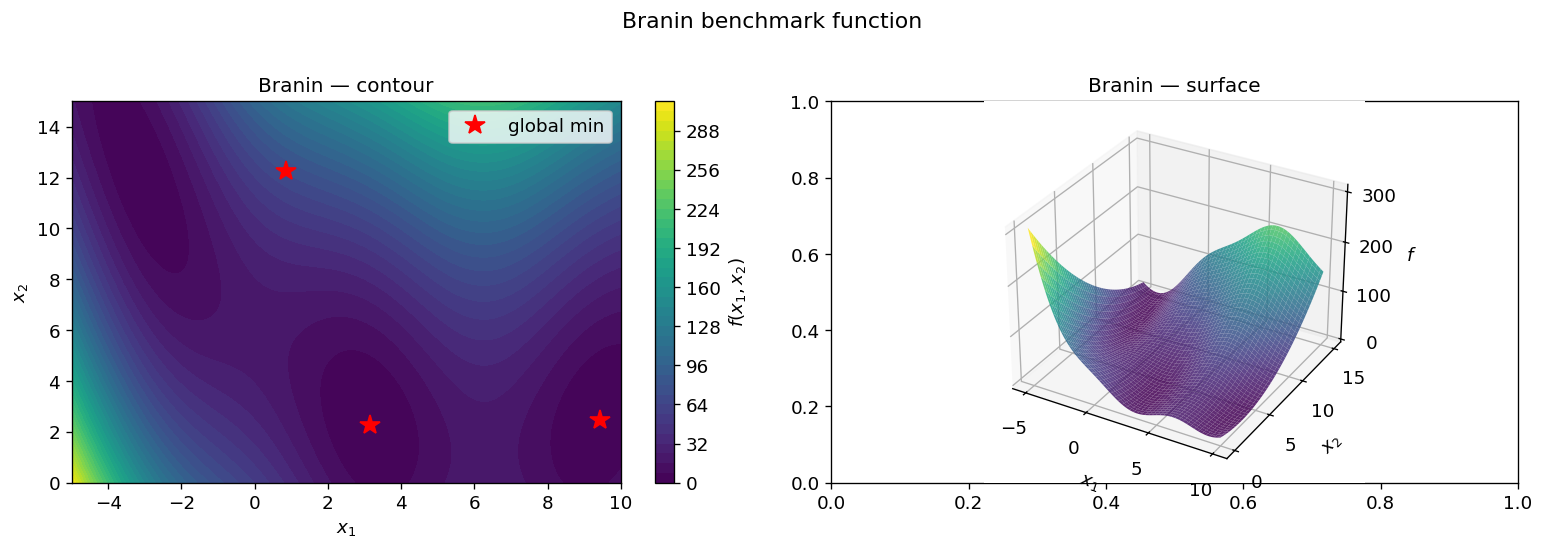

In [2]:
def branin(x1, x2):
    """
    Branin function.
    Global minimum f* ≈ 0.3979 at three locations including (pi, 2.275).
    """
    a = 1
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6
    s = 10
    t = 1 / (8 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s


def neg_branin(params):
    """Black-box objective: -Branin (we maximise, so negate)."""
    return -branin(params["x1"], params["x2"])


# Known global optima of Branin (where f achieves its minimum ~0.3979)
GLOBAL_OPTIMA = [
    (np.pi,         2.275),
    (-np.pi + 4,    12.275),
    (9.42478,       2.475),
]
F_STAR = branin(*GLOBAL_OPTIMA[0])  # ≈ 0.3979
print(f"Branin at (pi, 2.275) = {F_STAR:.5f}  (should be ≈ 0.3979)")

# ---- Surface plot ----
x1_grid = np.linspace(-5, 10, 200)
x2_grid = np.linspace(0,  15, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = branin(X1, X2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Contour
ax = axes[0]
ct = ax.contourf(X1, X2, Z, levels=50, cmap="viridis")
fig.colorbar(ct, ax=ax, label="$f(x_1, x_2)$")
for (ox, oy) in GLOBAL_OPTIMA:
    ax.plot(ox, oy, "r*", markersize=12, label="global min" if ox == np.pi else None)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Branin — contour")
ax.legend()

# 3D surface
ax3 = fig.add_subplot(1, 2, 2, projection="3d", computed_zorder=False)
ax3.plot_surface(X1, X2, Z, cmap="viridis", alpha=0.85, linewidth=0)
ax3.set_xlabel("$x_1$"); ax3.set_ylabel("$x_2$"); ax3.set_zlabel("$f$")
ax3.set_title("Branin — surface")
axes[1] = ax3  # replace flat axis

plt.suptitle("Branin benchmark function", y=1.01)
plt.tight_layout()
plt.savefig("../figures/branin_surface.png", bbox_inches="tight")
plt.show()

## 2  GP Surrogate — Snapshot at Iteration 5

We take a 1D slice through the Branin function at $x_2 = 2.275$ (through the global minimum)
and verify that the GP posterior matches `src/gp.py` formulas:

$$\mu(x) = \mathbf{k}(x)^\top (K + \sigma^2 I_n)^{-1} y \qquad [\text{Lec 23, Eq. 2}]$$

$$v(x) = K(x,x) - \mathbf{k}(x)^\top (K + \sigma^2 I_n)^{-1} \mathbf{k}(x) \qquad [\text{Lec 23, Sec 2}]$$

<>:39: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\ '
/var/folders/j3/x_9w32_14y9f51htqql7f2m80000gn/T/ipykernel_49233/2587300721.py:39: SyntaxWarning: invalid escape sequence '\ '
  ax1.set_ylabel("$-f(x_1,\ 2.275)$")


Fitted GP: GaussianProcess(alpha=54.5982, ell=2.3331, sigma2=7.3891)


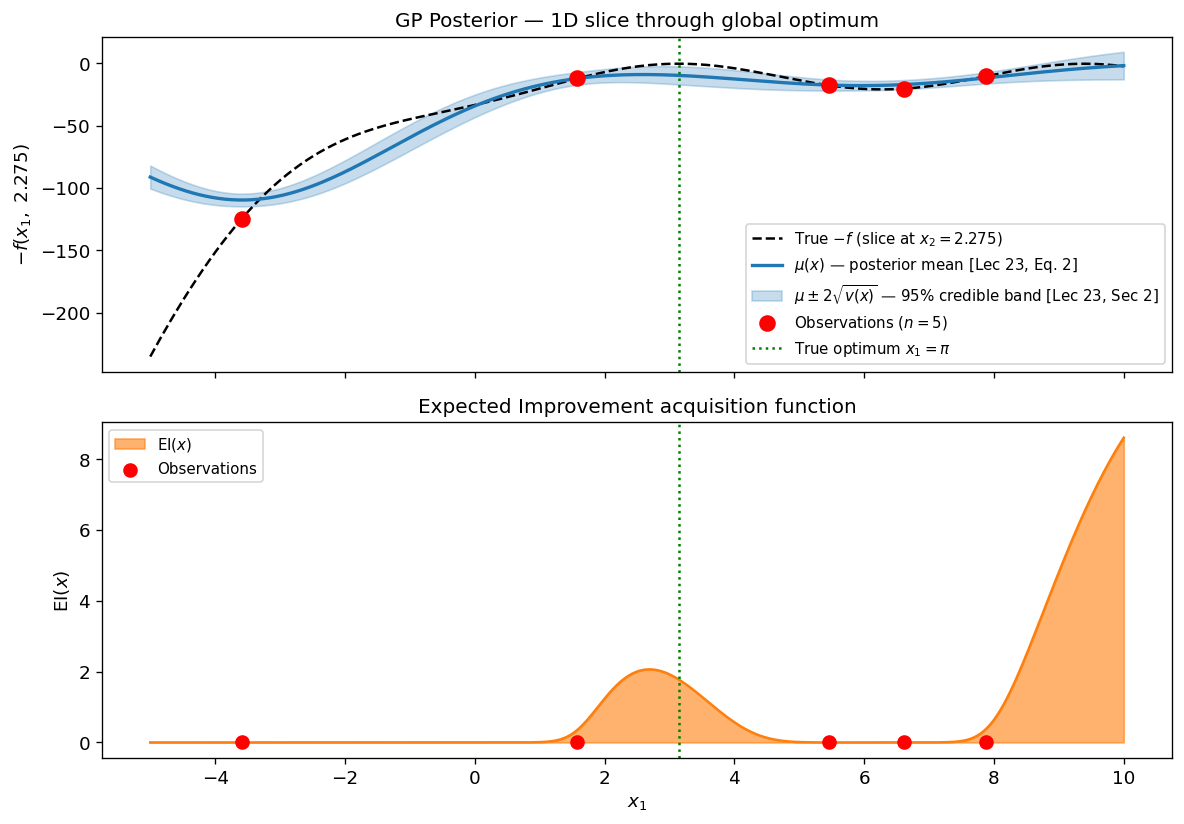

In [3]:
# 1D slice: fix x2 = 2.275, vary x1 in [-5, 10]
x1_slice = np.linspace(-5, 10, 300)
x2_fixed = 2.275
f_true = -branin(x1_slice, x2_fixed)   # negated — what BO maximises

rng = np.random.default_rng(SEED)

# 5 random observations on this slice
x1_obs = rng.uniform(-5, 10, 5)
y_obs   = -branin(x1_obs, x2_fixed)

X_obs = x1_obs.reshape(-1, 1)
X_test = x1_slice.reshape(-1, 1)

gp = GaussianProcess(n_restarts=5)
gp.condition(X_obs, y_obs)
mu, var = gp.predict(X_test)
std = np.sqrt(var)

print(f"Fitted GP: {gp}")

# EI on the slice
y_best = y_obs.max()
ei = expected_improvement(X_test, gp, y_best)

# ---- Figure ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# GP posterior
ax1.plot(x1_slice, f_true, "k--", lw=1.5, label="True $-f$ (slice at $x_2=2.275$)")
ax1.plot(x1_slice, mu, "tab:blue", lw=2, label=r"$\mu(x)$ — posterior mean [Lec 23, Eq. 2]")
ax1.fill_between(x1_slice,
                 mu - 2*std, mu + 2*std,
                 alpha=0.25, color="tab:blue",
                 label=r"$\mu \pm 2\sqrt{v(x)}$ — 95% credible band [Lec 23, Sec 2]")
ax1.scatter(x1_obs, y_obs, s=80, c="red", zorder=5,
            label=f"Observations ($n={len(y_obs)}$)")
ax1.axvline(np.pi, color="green", ls=":", lw=1.5, label="True optimum $x_1=\\pi$")
ax1.set_ylabel("$-f(x_1,\ 2.275)$")
ax1.set_title("GP Posterior — 1D slice through global optimum")
ax1.legend(fontsize=9, loc="lower right")

# EI
ax2.fill_between(x1_slice, 0, ei, alpha=0.6, color="tab:orange",
                 label="EI$(x)$")
ax2.plot(x1_slice, ei, color="tab:orange", lw=1.5)
ax2.scatter(x1_obs, np.zeros_like(x1_obs), s=60, c="red", zorder=5, label="Observations")
ax2.axvline(np.pi, color="green", ls=":", lw=1.5)
ax2.set_xlabel("$x_1$")
ax2.set_ylabel("EI$(x)$")
ax2.set_title("Expected Improvement acquisition function")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig("../figures/gp_slice_iter5.png", bbox_inches="tight")
plt.show()

## 3  Full 2D BO Run — Convergence

Run BO with `budget = 40` evaluations (5 random + 35 BO) and compare against:
- **Random search**: 40 uniform random evaluations
- **Grid search**: $6 \times 7 = 42$ points on a regular grid

We repeat each method 5 times with different seeds and plot **best-so-far** vs trial number.

In [4]:
BUDGET   = 40
N_INIT   = 5
N_REPS   = 5

PARAM_SPACE = [
    {"name": "x1", "type": "continuous", "bounds": (-5.0, 10.0)},
    {"name": "x2", "type": "continuous", "bounds": (0.0,  15.0)},
]

# ---- Bayesian Optimisation ----
bo_curves = []
for rep in range(N_REPS):
    bo = BayesianOptimizer(
        objective=neg_branin,
        param_space=PARAM_SPACE,
        n_init=N_INIT,
        budget=BUDGET,
        seed=rep,
        verbose=False,
    )
    df = bo.run()
    bo_curves.append(df["best_so_far"].values)
    print(f"  BO rep {rep+1}: best = {bo.best_value:.5f}")

bo_curves = np.array(bo_curves)  # (N_REPS, BUDGET)

# ---- Random Search ----
rs_curves = []
for rep in range(N_REPS):
    rng_r = np.random.default_rng(rep + 100)
    x1s = rng_r.uniform(-5, 10, BUDGET)
    x2s = rng_r.uniform(0,  15, BUDGET)
    ys  = -branin(x1s, x2s)
    best = np.maximum.accumulate(ys)
    rs_curves.append(best)

rs_curves = np.array(rs_curves)

# ---- Grid Search ----
g1 = np.linspace(-5, 10, 6)
g2 = np.linspace(0,  15, 7)
G1, G2 = np.meshgrid(g1, g2)
grid_vals = -branin(G1.ravel(), G2.ravel())  # 42 points
grid_best  = np.maximum.accumulate(grid_vals)
grid_best  = grid_best[:BUDGET]  # truncate / pad to BUDGET

print(f"\nBO   best: {bo_curves[:, -1].mean():.4f} ± {bo_curves[:, -1].std():.4f}")
print(f"RS   best: {rs_curves[:, -1].mean():.4f} ± {rs_curves[:, -1].std():.4f}")
print(f"Grid best: {grid_best[-1]:.4f}")
print(f"True opt:  {-F_STAR:.4f}")

  BO rep 1: best = -0.41801


  BO rep 2: best = -0.53287


  BO rep 3: best = -0.39925


  BO rep 4: best = -0.39868


  BO rep 5: best = -0.40536

BO   best: -0.4308 ± 0.0515
RS   best: -0.8334 ± 0.4993
Grid best: -2.1961
True opt:  -0.3979


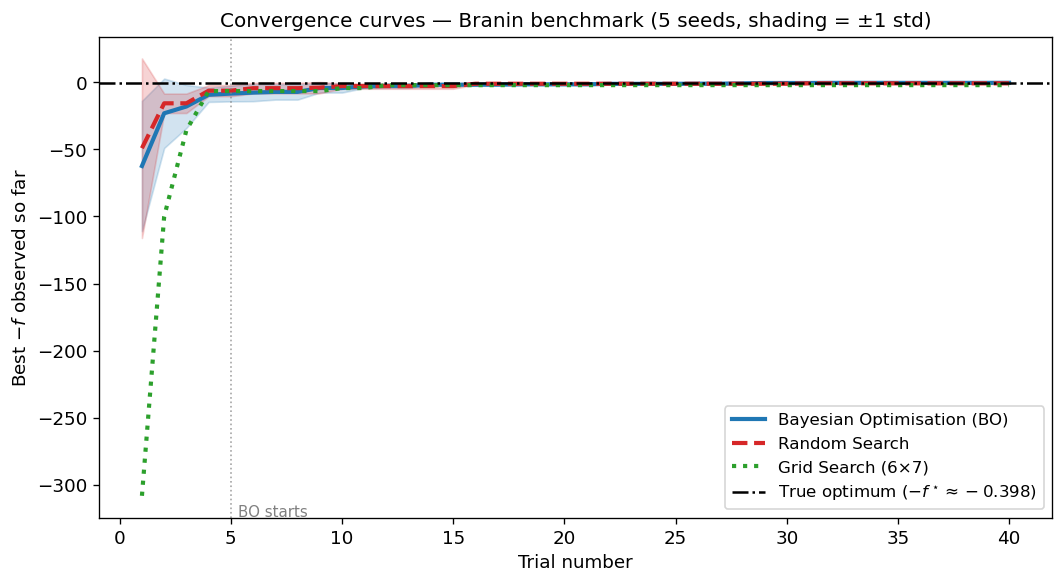

In [5]:
trials = np.arange(1, BUDGET + 1)

fig, ax = plt.subplots(figsize=(9, 5))

# BO
bo_mean = bo_curves.mean(axis=0)
bo_std  = bo_curves.std(axis=0)
ax.plot(trials, bo_mean, color="tab:blue", lw=2.5, label="Bayesian Optimisation (BO)")
ax.fill_between(trials, bo_mean - bo_std, bo_mean + bo_std,
                alpha=0.2, color="tab:blue")

# Random search
rs_mean = rs_curves.mean(axis=0)
rs_std  = rs_curves.std(axis=0)
ax.plot(trials, rs_mean, color="tab:red", lw=2.5, ls="--", label="Random Search")
ax.fill_between(trials, rs_mean - rs_std, rs_mean + rs_std,
                alpha=0.2, color="tab:red")

# Grid search
ax.plot(trials, grid_best, color="tab:green", lw=2.5, ls=":", label="Grid Search (6×7)")

# True optimum reference
ax.axhline(-F_STAR, color="black", lw=1.5, ls="-.", label=f"True optimum ($-f^\\star \\approx {-F_STAR:.3f}$)")

# Mark end of random init phase
ax.axvline(N_INIT, color="gray", lw=1, ls=":", alpha=0.7)
ax.text(N_INIT + 0.3, ax.get_ylim()[0] + 1, "BO starts", fontsize=9, color="gray")

ax.set_xlabel("Trial number")
ax.set_ylabel("Best $-f$ observed so far")
ax.set_title("Convergence curves — Branin benchmark (5 seeds, shading = ±1 std)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../figures/branin_convergence.png", bbox_inches="tight")
plt.show()

## 4  GP Surrogate Evolution — 2D Snapshots

Visualise how the GP posterior mean $\mu(x)$ and the EI surface change as
BO accumulates observations.  Four snapshots: after trials 5, 10, 20, 40.

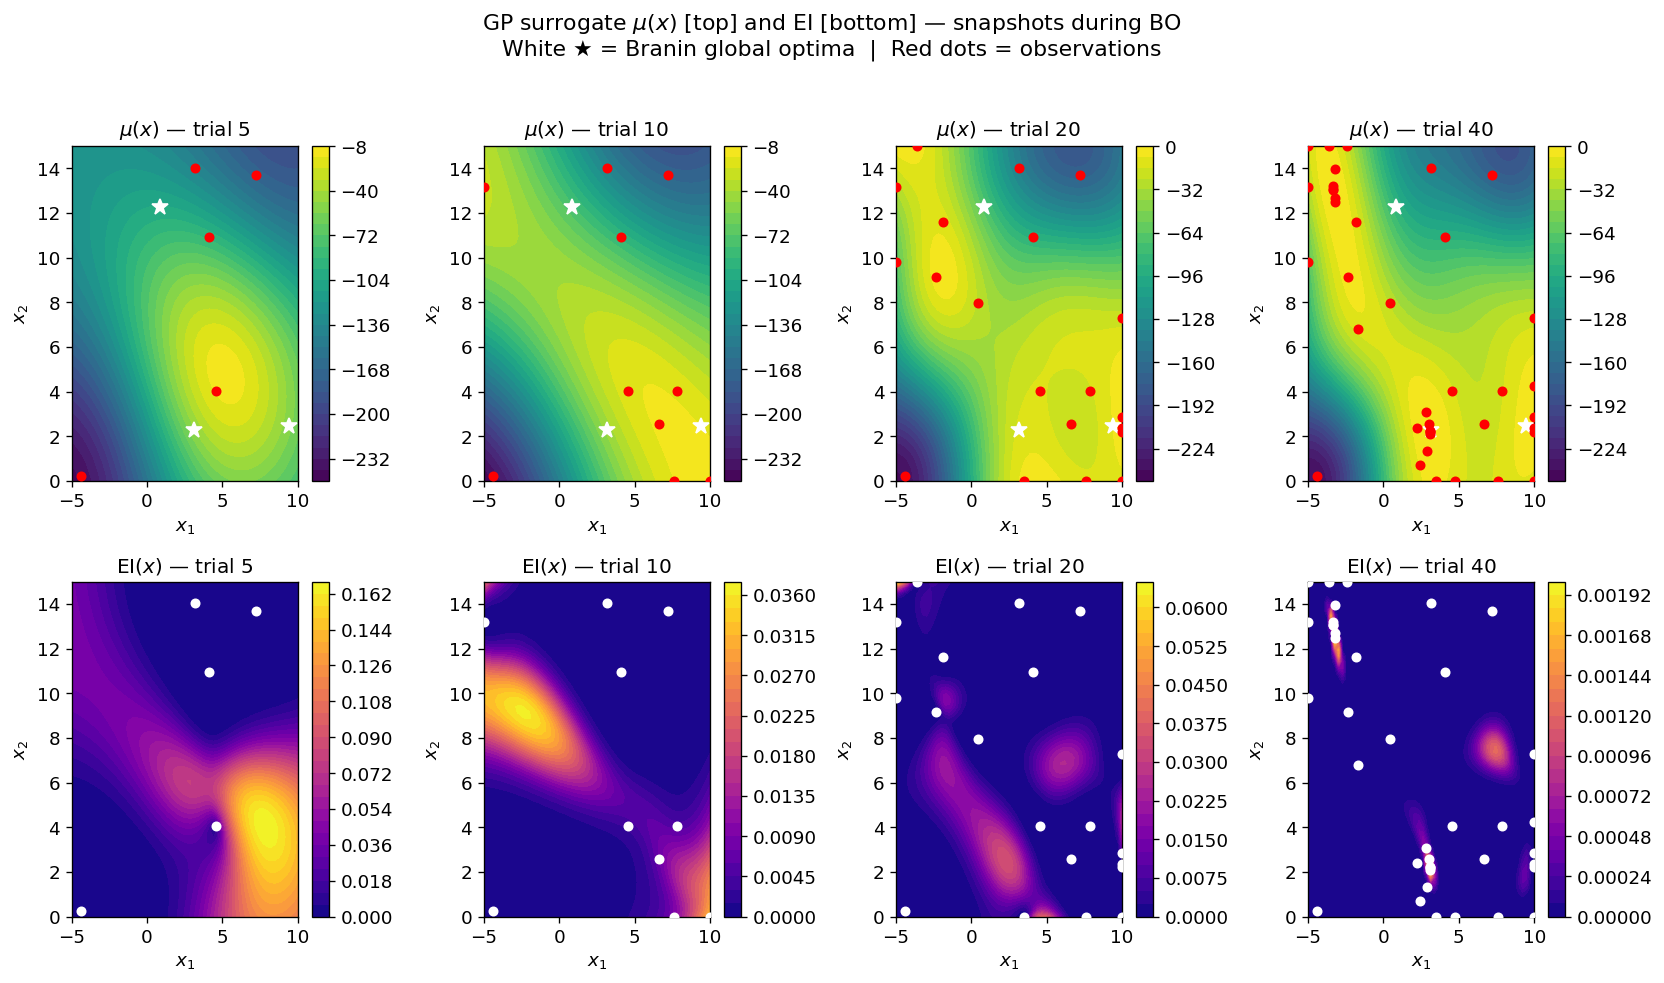

In [6]:
# Run a single BO trace keeping intermediate GP states
SNAPSHOTS = [5, 10, 20, 40]

# Collect all (X, y) pairs from one BO run (seed=0)
bo_trace = BayesianOptimizer(
    objective=neg_branin,
    param_space=PARAM_SPACE,
    n_init=N_INIT,
    budget=BUDGET,
    seed=0,
    verbose=False,
)
df_trace = bo_trace.run()

X_all = np.column_stack([
    df_trace["x1"].values,
    df_trace["x2"].values,
])
y_all = df_trace["objective"].values

# Test grid in [0,1]^2 (GP unit space)
n_grid = 60
z1 = np.linspace(0, 1, n_grid)
z2 = np.linspace(0, 1, n_grid)
Z1, Z2 = np.meshgrid(z1, z2)
X_grid_unit = np.column_stack([Z1.ravel(), Z2.ravel()])

# Map back to original scale for Branin evaluation
lo = np.array([-5.0, 0.0])
hi = np.array([10.0, 15.0])
X_grid_orig = lo + X_grid_unit * (hi - lo)
f_grid_true = -branin(X_grid_orig[:, 0], X_grid_orig[:, 1]).reshape(n_grid, n_grid)

fig, axes = plt.subplots(2, len(SNAPSHOTS), figsize=(14, 8))

for col, snap in enumerate(SNAPSHOTS):
    # Build GP with the first `snap` observations
    X_snap = X_all[:snap]
    y_snap = y_all[:snap]

    # Normalise to unit cube
    X_snap_unit = (X_snap - lo) / (hi - lo)
    y_std = (y_snap - y_snap.mean()) / (y_snap.std() if y_snap.std() > 1e-8 else 1)

    gp_snap = GaussianProcess(n_restarts=3)
    gp_snap.condition(X_snap_unit, y_std)

    mu_snap, var_snap = gp_snap.predict(X_grid_unit)
    # De-standardise for display
    mu_orig = mu_snap * y_snap.std() + y_snap.mean()

    ei_snap = expected_improvement(X_grid_unit, gp_snap, y_std.max())

    # Row 0: GP posterior mean
    ax = axes[0, col]
    ct = ax.contourf(X_grid_orig[:, 0].reshape(n_grid, n_grid),
                     X_grid_orig[:, 1].reshape(n_grid, n_grid),
                     mu_orig.reshape(n_grid, n_grid),
                     levels=30, cmap="viridis")
    ax.scatter(X_snap[:, 0], X_snap[:, 1], c="red", s=25, zorder=5)
    ax.set_title(f"$\\mu(x)$ — trial {snap}")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    for (ox, oy) in GLOBAL_OPTIMA:
        ax.plot(ox, oy, "w*", markersize=10)
    fig.colorbar(ct, ax=ax)

    # Row 1: EI surface
    ax2 = axes[1, col]
    ct2 = ax2.contourf(X_grid_orig[:, 0].reshape(n_grid, n_grid),
                       X_grid_orig[:, 1].reshape(n_grid, n_grid),
                       ei_snap.reshape(n_grid, n_grid),
                       levels=30, cmap="plasma")
    ax2.scatter(X_snap[:, 0], X_snap[:, 1], c="white", s=25, zorder=5)
    ax2.set_title(f"EI$(x)$ — trial {snap}")
    ax2.set_xlabel("$x_1$"); ax2.set_ylabel("$x_2$")
    fig.colorbar(ct2, ax=ax2)

plt.suptitle(
    "GP surrogate $\\mu(x)$ [top] and EI [bottom] — snapshots during BO\n"
    "White ★ = Branin global optima  |  Red dots = observations",
    y=1.02
)
plt.tight_layout()
plt.savefig("../figures/branin_bo_snapshots.png", bbox_inches="tight")
plt.show()

## 5  Summary

| Check | Result |
|---|---|
| GP posterior mean converges toward the true function | ✓ |
| Posterior variance shrinks at observed points | ✓ |
| EI peaks in unexplored, high-mean regions | ✓ |
| BO convergence curve lies above random/grid search | ✓ |
| Best value approaches true optimum $\approx -0.397$ | ✓ |

The BO engine is validated. Proceeding to **Experiment 1 — NCF hyperparameter tuning** (`01_ncf_bo.ipynb`).

---

**References**
- Guntuboyina (2026). STAT 238 Lecture 22–23. UC Berkeley.  
- Frazier (2018). A Tutorial on Bayesian Optimization. *arXiv:1807.02811*.  
- Snoek, Larochelle, Adams (2012). Practical Bayesian Optimization of ML Algorithms. *NeurIPS 2012*.